# Homework 8: Sample Sizes and Confidence Intervals

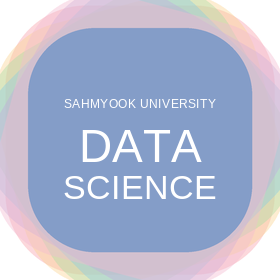

**Helpful Resource:**

- [Python Reference](http://data8.org/sp26/reference/): Cheat sheet of helpful array & table methods used in this data science course!

**Recommended Readings**: 

* [Estimation](https://inferentialthinking.com/chapters/13/Estimation.html)
* [Why the Mean Matters](https://inferentialthinking.com/chapters/14/Why_the_Mean_Matters.html)

In [ ]:
# Setup (run this first!)
!pip install -q otter-grader datascience
!git clone https://github.com/jihyungkim94/datascience.git 2>/dev/null || true
import os, json
os.chdir('/content/datascience/hw/hw08')
os.makedirs('tests', exist_ok=True)
with open('hw08.ipynb') as _f:
    _nb = json.load(_f)
for _name, _test in _nb['metadata']['otter']['tests'].items():
    with open('tests/' + _name + '.py', 'w') as _f:
        _f.write('OK_FORMAT = True\n\ntest = ' + repr(_test) + '\n')
import otter
grader = otter.Notebook('hw08.ipynb')
print('Ready! (17 tests loaded)')

Please complete this notebook by filling in the cells provided. **Before you begin, execute the cell below to setup the notebook by importing some helpful libraries.** Each time you start your server, you will need to execute this cell again.

Throughout this homework and all future ones, **please be sure to not re-assign variables throughout the notebook!** For example, if you use `max_temperature` in your answer to one question, do not reassign it later on. Otherwise, you will fail tests that you thought you were passing previously!

Directly sharing answers is not okay, but discussing problems with the course staff or with other students is encouraged.

You should start early so that you have time to get help if you're stuck.

In [ ]:
# Don't change this cell; just run it. 

import numpy as np
from datascience import *
from math import *

# These lines do some fancy plotting magic.
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 1. Bounding the Tail of a Distribution

A community has an average age of 45 years with a standard deviation of 5 years. **We do not know how the ages are distributed.**

In each part below, fill in the blank with a percent that makes the statement true **without further assumptions**, and **explain your answer**.

*Note:* **Do not round your answers.** Give the best answer that is possible with the information given.

> ***Please review [Section 14.2](https://inferentialthinking.com/chapters/14/2/Variability.html) and [Section 14.2.5](https://inferentialthinking.com/chapters/14/2/Variability.html#chebychev-s-bounds) of the textbook before proceeding with this section. You will be able to understand and solve the problems more efficiently!***

<hr style="border: 1px solid #7a98c7;" />

**Question 1.1.** Answer the following statement: At least _______% of the people are between 25 and 65 years old. Assign your answer (a number between 0 and 100 without the % symbol) to the variable `q1_1_percentage`. 

Next, select **all** valid reasons why you chose your answer, and assign them to the array `q1_1_reasoning`.

1. We must use Chebyshev’s inequality to create a bound on the percentage of people between 25 and 65 years old because we cannot make any assumptions about the distribution of ages within the community.
2. We can use what we know about the Normal distribution to create a bound on the percentage of people between 25 and 65 years old because we can assume the distribution of ages within the community are normally distributed.
3. 25 is 4 SDs below the mean and 65 is 4 SDs above the mean, so our bound is in the range between +/- 4 SDs from the mean.
4. 25 is 2 SDs below the mean and 65 is 2 SDs above the mean, so our bound is in the range between +/- 2 SDs from the mean.

 **(6 Points)**

In [ ]:
q1_1_percentage = ...
q1_1_reasoning = make_array(...)

In [ ]:
grader.check("q1_1")

<hr style="border: 1px solid #7a98c7;" />

**Question 1.2.** Answer the following statement: At most _______% of the people have ages that are not in the range 25 years to 65 years. Assign your answer (a number between 0 and 100 without the % symbol) to the variable `q1_2_percentage`. 

Next, explain your answer by assigning **one** of the following statements to the variable `q1_2_reasoning`. *Hint: Consider what relationship exists between your answer to 1.1 and 1.2, and recall the percentage value you stored in `q1_1_percentage`!*

1. Since we know that at least `q1_1_percentage`% of the people are between 25 and 65 years old, we subtract that from 100% to determine the maximum percentage of people that are not in this range.
2. Since we know that at least `q1_1_percentage`% of the people are between 25 and 65 years old, we divide by 2 to determine the maximum percentage of people that are not in this range.
3. Since we know that at least `q1_1_percentage`% of the people are between 25 and 65 years old, we subtract that from 100% and divide the difference by 2 to determine the maximum percentage of people that are not in this range.

 **(6 Points)**

In [ ]:
q1_2_percentage = ...
q1_2_reasoning = ...

In [ ]:
grader.check("q1_2")

<hr style="border: 1px solid #7a98c7;" />

**Question 1.3.** Answer the following statement: At most _______% of the people are more than 65 years old. Assign your answer (a number between 0 and 100 without the % symbol) to the variable `q1_3_percentage`.

Next, explain your answer by assigning **one** of the following statements to the variable `q1_3_reasoning`.

*Hint:* If you're stuck, try thinking about what the distribution may look like in this case.

1. Since the distribution is symmetric around the mean, at most half of the people outside the 25 to 65 years range must be more than 65 years old.
2. Since we do not know anything about the distribution, at most half of the people outside the 25 to 65 years range must be more than 65 years old. 
3. Since the distribution is symmetric around the mean, the maximum possible percentage of people more than 65 years old is the same as the maximum amount of people that are not in the 25 to 65 years range.
4. Since we do not know anything about the distribution, the maximum possible percentage of people more than 65 years old is the same as the maximum amount of people that are not in the 25 to 65 years range.

**(6 Points)**


In [ ]:
q1_3_percentage = ...
q1_3_reasoning = ...

In [ ]:
grader.check("q1_3")

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 2. Sample Size and Confidence Level

A data science class at the large Data Science University wants to estimate the percent of Facebook users among students at the school. To do this, they need to take a random sample of students. You can assume that their method of sampling is equivalent to drawing at random with replacement from students at the school.

> ***Please review [Section 14.6](https://inferentialthinking.com/chapters/14/6/Choosing_a_Sample_Size.html#) of the textbook before proceeding with this section. There is a helpful formula that will help you solve the problems!***

<hr style="border: 1px solid #7a98c7;" />

**Question 2.1.** Assign `smallest` to the smallest number of students they should sample to ensure that a **95%** confidence interval for the parameter has a width of no more than 6% from left end to right end. **(6 points)**

*Hint:* How can our data be represented to show if a student in the sample is a Facebook user or not? Given this, what assumptions can we make for the SD of the population? [Section 14.6](https://inferentialthinking.com/chapters/14/6/Choosing_a_Sample_Size.html#) might be helpful!

*Note:* The `ceil` function will round up a float to the next highest integer. While your calculations for the smallest possible sample size may result in a float, a sample size must always be an integer. Write your calculations for the smallest possible sample size inside of `ceil(...)` to ensure that `smallest` is assigned to the smallest integer sample size that will satisfy our width requirements.


In [ ]:
smallest = ceil(...)
smallest

In [ ]:
grader.check("q2_1")

<hr style="border: 1px solid #7a98c7;" />

**Question 2.2.** Suppose the data science class decides to construct a 90% confidence interval instead of a 95% confidence interval, but they still require that the width of the interval is no more than 6% from left end to right end. Will they need the same sample size as in 2.1? Assign `sample_size_answer` to the correct answer. **(6 Points)**

1. Yes, they must use the same sample size, because the maximum width of the confidence interval has not changed.

2. No, a smaller sample size will work. A 90% confidence interval spans fewer standard deviations than a 95% confidence interval, so a smaller sample size can achieve the same maximum width of 6%.

3. No, they will need a bigger sample. A 90% confidence interval spans more standard deviations than a 95% confidence interval, so a larger sample size is needed to achieve the same maximum width of 6%.


In [ ]:
sample_size_answer = ...
sample_size_answer

In [ ]:
grader.check("q2_2")

<hr style="border: 1px solid #7a98c7;" />

**Question 2.3.** The professor tells the class that a 90% confidence interval for the parameter is constructed exactly like a 95% confidence interval, except that you have to go only **1.65 SDs** on either side of the estimate (±1.65) instead of **2 SDs** on either side (±2). Assign `smallest_num` to the smallest number of students they should sample to ensure that a **90%** confidence interval for the parameter has a **width of no more than 6%** from left end to right end. **(6 points)**

*Note:* The `ceil` function will round up a float to the next highest integer. While your calculations for the smallest possible sample size may result in a float, a sample size must always be an integer. Write your calculations for the smallest possible sample size inside of `ceil(...)` to ensure that `smallest_num` is assigned to the smallest integer sample size that will satisfy our width requirements.


In [ ]:
smallest_num = ceil(...)
smallest_num

In [ ]:
grader.check("q2_3")

For this next exercise, please consult [Section 14.3.4](https://inferentialthinking.com/chapters/14/3/SD_and_the_Normal_Curve.html#the-standard-normal-cdf) of the textbook for similar examples.

Richard and Noah are curious about how the professor came up with the value 1.65 in Question 2.3. The professor says he ran the following two code cells. The first one calls the `datascience` library function `plot_normal_cdf`, which displays the proportion that is at most the specified number of SDs above average under the normal curve plotted with standard units on the horizontal axis. You can find the documentation [in the datascience documentation](http://data8.org/datascience/util.html#datascience.util.plot_normal_cdf).

*Note:* The acronym `cdf` stands for `cumulative distribution function`. It measures the proportion to the left of a specified point under a probability histogram.

In [ ]:
plot_normal_cdf(1.65)

To run the second cell, the professor had to first import a Python library for probability and statistics:

In [ ]:
# Just run this cell
from scipy import stats

Then he used the `norm.cdf` method in the library to find the gold proportion above.

In [ ]:
# Just run this cell
stats.norm.cdf(1.65)

This means that roughly 95% of our data lies to the left of +1.65 SDs from the mean (the shaded area in yellow above).

*Note*: You do not need to understand how the `scipy` library or how to use the method yourself.

<hr style="border: 1px solid #7a98c7;" />

**Question 2.4.** The cell above shows that in a normal distribution, about **95%** of the data is less than or equal to **1.65 SDs** above average. Therefore, what can we say about the right number of SDs to use when constructing a **90%** confidence interval? Select all valid statements, and assign your answers to the array `sd_answers`. **(6 Points)**

1.  A **90%** confidence interval should be contained in about **1.65 SDs** above and below the center because this captures the middle **90%** of a normal distribution.

2. A **90%** confidence interval should be contained in about **2 SDs** above and below the center because it is the standard cutoff for normal distributions.

3. A **90%** confidence interval should be contained in about **0.90 SDs** above and below the center because the confidence level is **90%**.

4. A **90%** confidence interval should cover from the left end of the distribution up to **+1.65 SDs** above the center, since **95%** of values are below that point.

5. Because the normal distribution is symmetric, if about **5%** of values are above **+1.65 SDs**, then about 5% are below **−1.65 SDs**, so a **90%** confidence interval uses **±1.65 SDs**.

6. Because the normal distribution is symmetric, if about **5%** of values are above **+2 SDs**, then about 5% are below **−2 SDs**, so a **90%** confidence interval uses **±2 SDs**.

In [ ]:
sd_answers = make_array(...)

In [ ]:
grader.check("q2_4")

In [ ]:
# Just run this cell, do not change it.
stats.norm.cdf(2.33)

<hr style="border: 1px solid #7a98c7;" />

**Question 2.5.** The cell above shows that the proportion that is at most 2.33 SDs above average in a normal distribution is 99%. Assign `option` to the right option to fill in the blank: **(6 points)**

If you start at the estimate and go 2.33 SDs on either side, then you will get a _______% confidence interval for the parameter.

1. 99.5
2. 99
3. 98.5
4. 98

_Note:_ `option` should be assigned to one of `1`, `2`, `3`, or `4` depending on which answer is correct. 



In [ ]:
option = ...
option

In [ ]:
grader.check("q2_5")

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 3. Polling and the Normal Distribution

Marissa and Soumyadeep are a statistical consultants, and they are working for a group that supports Proposition 68 (which would mandate labeling of all horizontal and vertical axes, unrelated to any real California proposition) called Yes on 68.  They want to know how many Californians will vote for the proposition.

Marissa polls a random sample of all California voters, and she finds that 210 of the 400 sampled voters will vote in favor of the proposition. We have provided a table for you below which has 3 columns: the first two columns are identical to `sample`. The third column contains the proportion of total voters that chose each option.

In [ ]:
sample = Table().with_columns(
    "Vote",  make_array("Yes", "No"),
    "Count", make_array(210,   190))

sample_size = sum(sample.column("Count"))
sample_with_proportions = sample.with_column("Proportion", sample.column("Count") / sample_size)
sample_with_proportions

<hr style="border: 1px solid #7a98c7;" />

**Question 3.1.** Marissa wants to use 10,000 bootstrap resamples to compute a confidence interval for the proportion of all California voters who will vote Yes.  

Fill in the next cell to simulate an empirical distribution of Yes proportions. Use bootstrap resampling to simulate 10,000 election outcomes, and assign `resample_yes_proportions` to contain the Yes proportion of each bootstrap resample. Then, visualize `resample_yes_proportions` with a histogram. **You should see a bell shaped histogram centered near the proportion of Yes in the original sample.** **(6 points)**

*Hint:* `sample_proportions` may be useful here!


In [ ]:
resample_yes_proportions = make_array()
for i in np.arange(10000):
    resample = ...
    resample_yes_proportions = ...
Table().with_column("Resample Yes proportion", resample_yes_proportions).hist(bins=np.arange(.2, .8, .01))

In [ ]:
grader.check("q3_1")

<hr style="border: 1px solid #7a98c7;" />

**Question 3.2.** Consider the histogram of bootstrap resampled Yes proportions above. Which of the following statements about this distribution and the Central Limit Theorem are true? Assign your answers to the array `clt_answers`. We recommend reviewing [14.4](https://inferentialthinking.com/chapters/14/4/Central_Limit_Theorem.html) for a refresher on the CLT. **(6 points)**

1. If we think of Yes votes as 1s and No votes as 0s, each resampled Yes proportion is the mean of a bootstrap resample of 1s and 0s taken with replacement from the original sample, so the Central Limit Theorem applies when the sample size is large. 

2. Because the sample size of 400 voters is large, the Central Limit Theorem tells us that the bootstrap distribution of the sample Yes proportions will be approximately normal, meaning it's bell-shaped and symmetric.

3. The Central Limit Theorem applies only when the population itself follows a normal distribution.

4. The bootstrap distribution is centered around the proportion of Yes votes in the original sample (210/400).

5. The boostrap distribution should be centered at 0.5, since there are only two possible outcomes (Yes or No).


In [ ]:
clt_answers = make_array(...)

In [ ]:
grader.check("q3_2")

<hr style="border: 1px solid #7a98c7;" />

In a population whose members are represented as either a 0 or 1, there is a simple formula for the **standard deviation of that population**:

$$\text{standard deviation of population} = \sqrt{(\text{proportion of 0s}) \times (\text{proportion of 1s})}$$

(Figuring out this formula, starting from the definition of the standard deviation, is a fun exercise for those who enjoy algebra.)

**Question 3.3.** Using only the Central Limit Theorem and the numbers of Yes and No voters in our sample of 400, *algebraically* compute the predicted standard deviation of the `resample_yes_proportions` array. Assign this number to `approximate_sd`. **Do not access the data in `resample_yes_proportions` in any way.** **(6 points)**

Remember that the standard deviation of the sample means can be computed from the population SD and the size of the sample (the formula above might be helpful). If we do not know the population SD, we can use the sample SD as a reasonable approximation in its place. 

_Note:_ Section [14.5.1](https://inferentialthinking.com/chapters/14/5/Variability_of_the_Sample_Mean.html#the-sd-of-all-the-sample-means) of the textbook may be helpful.


In [ ]:
approx_pop_sd = ...
approximate_sd = ...
approximate_sd

In [ ]:
grader.check("q3_3")

**Question 3.4.** Compute the standard deviation of the array `resample_yes_proportions`, which will act as an approximation to the true SD of the possible sample proportions. This will help verify whether your answer to question 3.3 is approximately correct. **(6 points)**


In [ ]:
exact_sd = ...
exact_sd

In [ ]:
grader.check("q3_4")

<hr style="border: 1px solid #7a98c7;" />

**Question 3.5.** **Again, without accessing `resample_yes_proportions` in any way**, compute an approximate 95% confidence interval for the proportion of Yes voters in California. **(6 points)**

The cell below draws your interval as a red bar below the histogram of `resample_yes_proportions`; use that to verify that your answer looks right.

*Hint:* How many SDs corresponds to 95% of the distribution promised by the CLT? Recall the discussion in the textbook [in the textbook's normal curve section](https://inferentialthinking.com/chapters/14/3/SD_and_the_Normal_Curve.html).

*Hint:* The `approximate_sd` variable you previously defined may be helpful!


In [ ]:
lower_limit = ...
upper_limit = ...
print('lower:', lower_limit, 'upper:', upper_limit)

In [ ]:
grader.check("q3_5")

In [ ]:
# Run this cell to plot your confidence interval.
Table().with_column("Resample Yes proportion", resample_yes_proportions).hist(bins=np.arange(.2, .8, .01))
plt.plot(make_array(lower_limit, upper_limit), make_array(0, 0), c='r', lw=10);

Your confidence interval should overlap the number 0.5.  That means we can't be very sure whether Proposition 68 is winning, even though the sample Yes proportion is a bit above 0.5.

The Yes on 68 campaign really needs to know whether they're winning.  It's impossible to be absolutely sure without polling the whole population, but they'd be okay if the standard deviation of the sample mean were only 0.005.  They ask Marissa to run a new poll with a sample size that's large enough to achieve that.  (Polling is expensive, so the sample also shouldn't be bigger than necessary.)

Marissa consults Chapter 14 of the textbook.  Instead of making the conservative assumption that the population standard deviation is 0.5 (coding Yes voters as 1 and No voters as 0), she decides to assume that it's equal to the standard deviation of the sample,

$$\sqrt{(\text{Yes proportion in the sample}) \times (\text{No proportion in the sample})}.$$

**Under that assumption, Marissa decides that a sample size of 9,975 would suffice.**

Does Marissa's sample size achieve the desired standard deviation of sample means? What SD would you achieve with a smaller sample size? A higher sample size?

<hr style="border: 1px solid #7a98c7;" />

**Question 3.6.** To explore this, first compute the SD of sample means obtained by using Marissa's sample size and assign it to `marissa_sample_mean_sd`. **(6 points)**


In [ ]:
estimated_population_sd = ...
marissa_sample_size = ...
marissa_sample_mean_sd = ...
print("With Marissa's sample size, you would predict a sample mean SD of %f." % marissa_sample_mean_sd)

In [ ]:
grader.check("q3_6")

<hr style="border: 1px solid #7a98c7;" />

**Question 3.7.** Next, compute the SD of sample means that you would get from a smaller sample size. Ideally, you should pick a number that is significantly smaller, but any sample size smaller than Marissa's will do. **(5 points)**


In [ ]:
smaller_sample_size = ...
smaller_sample_mean_sd = ...
print("With this smaller sample size, you would predict a sample mean SD of %f" % smaller_sample_mean_sd)

In [ ]:
grader.check("q3_7")

<hr style="border: 1px solid #7a98c7;" />

**Question 3.8.** Finally, compute the SD of sample means that you would get from a larger sample size. Here, a number that is significantly larger would make any difference more obvious, but any sample size larger than Marissa's will do. **(5 points)**

In [ ]:
larger_sample_size = ...
larger_sample_mean_sd = ...
print("With this larger sample size, you would predict a sample mean SD of %f" % larger_sample_mean_sd)

In [ ]:
grader.check("q3_8")

<hr style="border: 1px solid #7a98c7;" />

**Question 3.9.** Based off of this, was Marissa's sample size approximately the minimum sufficient sample, given her assumption that the sample SD is the same as the population SD? Assign `min_sufficient` to `True` if 9,975 was indeed approximately the minimum sufficient sample, and `False` if it wasn't. **(6 points)**


In [ ]:
min_sufficient = ...
min_sufficient

In [ ]:
grader.check("q3_9")

You're done with Homework 8!  

**Important submission steps:**
1. Run all the cells and verify that every test passes.
2. Choose **File → Download → Download .ipynb**.
3. Upload the `.ipynb` file to the LMS.

**Make sure every cell has been run before you download — the outputs are part of what you hand in.**


## Pets of this data science course

Biscuit and Sandie are proud of you for completing the assignment!

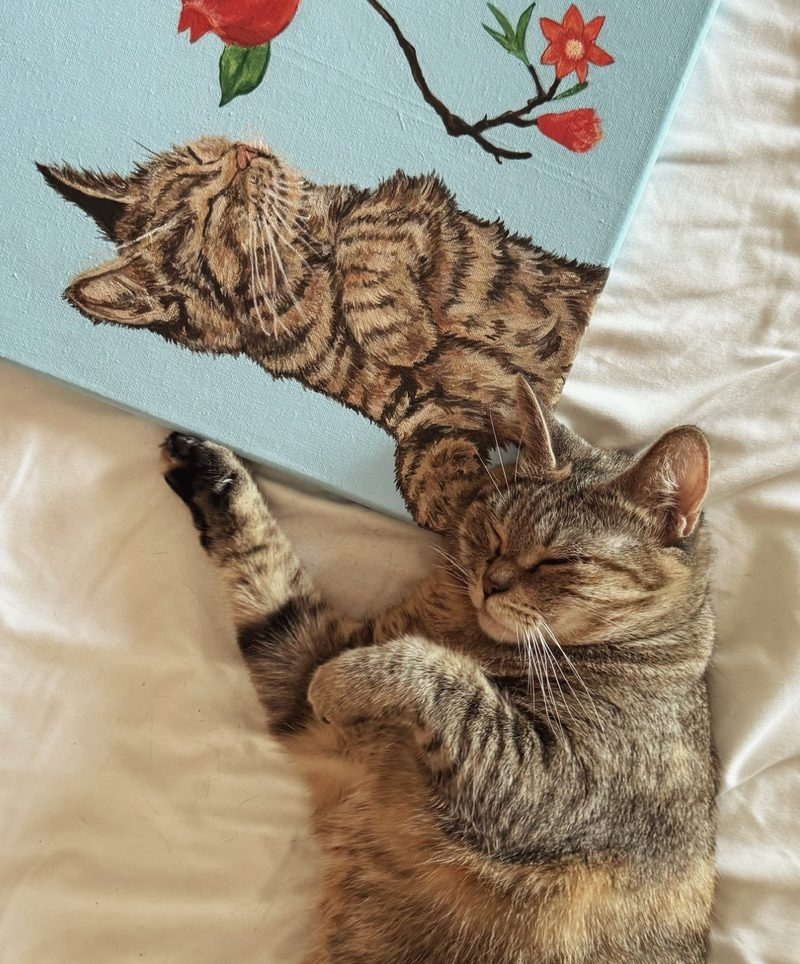
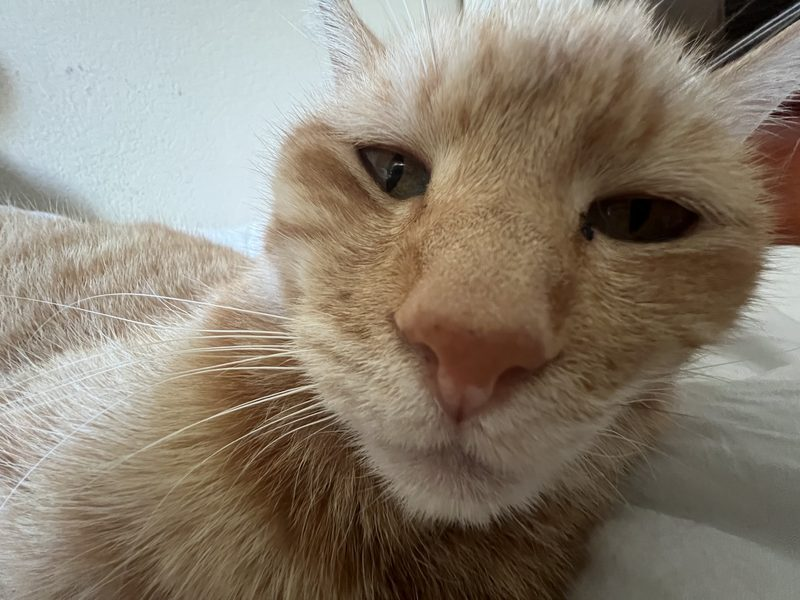

Congrats on finishing Homework 8!

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [ ]:
grader.check_all()

### Submission
1. Run `grader.check_all()` above and make sure all tests pass.
2. **File → Download → Download .ipynb**
3. Upload the `.ipynb` file to the LMS.

_(`grader.export()` does not work on Google Colab, so it has been removed.)_